# BirdCLEF+ 2026 - 234-class multi-label classifier

Trains a unified 234-class multi-label model so that the 28 species missing from `train_audio` (3 frogs + 25 insect sonotypes) are learned directly from `train_soundscapes_labels.csv`. Replaces the single-label fastai pipeline in `birdclef_plus_2026_sound_classification_attempt_1.ipynb`.

Inputs:
- Competition data (`/kaggle/input/competitions/birdclef-2026/`).
- One or more `species-XXX-YYY` Kaggle datasets produced by `scripts/generate_spectrogram_batches.py` (single-label train_audio PNGs, parent-folder = species).
- A soundscape spectrogram Kaggle dataset produced locally by `scripts/generate_soundscape_spectrograms.py` (PNGs + `soundscape_index.csv` with multi-label rows).

Outputs: `model_multilabel_234.pkl` and `vocab.json` for the submission notebook.

## Setup

In [1]:
! pip install -Uqq fastbook timm
import fastbook
fastbook.setup_book()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.9 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from fastbook import *
from fastai.vision.all import *
import json
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score


## Paths

Edit `SPECIES_FOLDERS` and `SOUNDSCAPE_DATASET_DIR` to point at the Kaggle datasets you uploaded. The competition data is mounted automatically via `kagglehub`.

In [3]:
import kagglehub
competition_dir = Path(kagglehub.competition_download('birdclef-2026'))
print('Competition dir:', competition_dir)

SPECIES_FOLDERS = [
    Path('/kaggle/input/datasets/ucheozoemena/species-001-010'),
    Path('/kaggle/input/datasets/ucheozoemena/species-011-090'),
]
SOUNDSCAPE_DATASET_DIR = Path('/kaggle/input/datasets/ucheozoemena/soundscape-spectrograms')

for p in SPECIES_FOLDERS + [SOUNDSCAPE_DATASET_DIR]:
    print(f'{p}: exists={p.exists()}')

Competition dir: /kaggle/input/competitions/birdclef-2026
/kaggle/input/datasets/ucheozoemena/species-001-010: exists=True
/kaggle/input/datasets/ucheozoemena/species-011-090: exists=True
/kaggle/input/datasets/ucheozoemena/soundscape-spectrograms: exists=True


## Build the unified multi-label dataframe

Two sources concatenated into one dataframe with columns `image_path, labels, source, group, is_valid`:
- **train_audio**: each PNG -> one positive label = parent folder name.
- **soundscapes**: each PNG -> the semicolon-joined multi-label string from `soundscape_index.csv`.

The `group` column gives a stable id for the validation split (parent species for train_audio, `BC2026_Train_NNNN` file id for soundscapes) so windows from the same recording never straddle the split.

In [4]:
import ast

MAX_PER_SPECIES = 500

# Build secondary-label lookup: filename stem -> list of valid secondary species.
# We filter against sample_submission columns so no out-of-vocab labels sneak in.
_valid_species = set(
    c for c in pd.read_csv(competition_dir / 'sample_submission.csv').columns
    if c != 'row_id'
)

def _parse_secondaries(val):
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return []
    try:
        result = ast.literal_eval(val)
        return [s for s in result if s and s in _valid_species]
    except Exception:
        return []

_train_csv = pd.read_csv(competition_dir / 'train.csv')
_secondary_lookup = dict(zip(
    _train_csv['filename'].apply(lambda f: Path(f).stem),
    _train_csv['secondary_labels'].apply(_parse_secondaries),
))

isolated_rows = []
for folder in SPECIES_FOLDERS:
    if not folder.exists():
        print(f'Skipping missing folder: {folder}')
        continue
    for png in get_image_files(folder):
        primary = png.parent.name
        secondaries = [s for s in _secondary_lookup.get(png.stem, []) if s != primary]
        isolated_rows.append({
            'image_path': str(png),
            'labels': ';'.join([primary] + secondaries),
            'primary_label': primary,
            'source': 'train_audio',
            'group': primary,
        })
isolated_df = pd.DataFrame(isolated_rows)

# Cap by primary species so common birds don't swamp rare ones.
isolated_df = (
    isolated_df
    .groupby('primary_label', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), MAX_PER_SPECIES), random_state=42))
    .reset_index(drop=True)
    .drop(columns='primary_label')
)

n_with_sec = isolated_df['labels'].str.contains(';').sum()
print(f'train_audio rows (capped at {MAX_PER_SPECIES}/species): {len(isolated_df)}')
print(f'unique primary species: {isolated_df["labels"].str.split(";").str[0].nunique()}')
print(f'rows with >=1 secondary label: {n_with_sec} ({100*n_with_sec/len(isolated_df):.1f}%)')


/tmp/ipykernel_24/278243999.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), MAX_PER_SPECIES), random_state=42))


train_audio rows (capped at 500/species): 85022
unique primary species: 206
rows with >=1 secondary label: 0 (0.0%)


In [5]:
soundscape_index = pd.read_csv(SOUNDSCAPE_DATASET_DIR / 'soundscape_index.csv')

def soundscape_group(image_name: str) -> str:
    # 'BC2026_Train_0001_S08_20250606_030007__s0.png' -> 'BC2026_Train_0001'
    parts = image_name.split('_')
    return '_'.join(parts[:3])

soundscape_df = pd.DataFrame({
    'image_path': [str(SOUNDSCAPE_DATASET_DIR / p) for p in soundscape_index['image_path']],
    'labels': soundscape_index['labels'],
    'source': 'soundscape',
    'group': soundscape_index['image_path'].map(soundscape_group),
})
print(f'soundscape rows: {len(soundscape_df)}')
print(f'unique soundscape file ids: {soundscape_df["group"].nunique()}')
soundscape_df.head()

soundscape rows: 739
unique soundscape file ids: 66


,image_path,labels,source,group
0,/kaggle/input/datasets/ucheozoemena/soundscape-spectrograms/BC2026_Train_0039_S22_20211231_201500__s0.png,22961;23158;24321;517063;65380,soundscape,BC2026_Train_0039
1,/kaggle/input/datasets/ucheozoemena/soundscape-spectrograms/BC2026_Train_0039_S22_20211231_201500__s5.png,22961;23158;24321;517063;65380,soundscape,BC2026_Train_0039
2,/kaggle/input/datasets/ucheozoemena/soundscape-spectrograms/BC2026_Train_0039_S22_20211231_201500__s10.png,22961;23158;24321;517063;65380,soundscape,BC2026_Train_0039
3,/kaggle/input/datasets/ucheozoemena/soundscape-spectrograms/BC2026_Train_0039_S22_20211231_201500__s15.png,22961;23158;24321;517063;65380,soundscape,BC2026_Train_0039
4,/kaggle/input/datasets/ucheozoemena/soundscape-spectrograms/BC2026_Train_0039_S22_20211231_201500__s20.png,22961;23158;24321;517063;65380,soundscape,BC2026_Train_0039


In [6]:
import hashlib

VAL_FRACTION = 0.2
SEED = 42

def stable_hash_in_valid(group: str, frac: float) -> bool:
    h = hashlib.md5(f'{group}:{SEED}'.encode()).digest()
    bucket = int.from_bytes(h[:4], 'big') / 2**32
    return bucket < frac

df = pd.concat([isolated_df, soundscape_df], ignore_index=True)
df['is_valid'] = df['group'].map(lambda g: stable_hash_in_valid(g, VAL_FRACTION))

print(f'total rows: {len(df)} (train={int((~df.is_valid).sum())}, valid={int(df.is_valid.sum())})')
print('source x split:')
print(df.groupby(['source', 'is_valid']).size())

total rows: 85761 (train=68151, valid=17610)
source x split:
source       is_valid
soundscape   False         581
             True          158
train_audio  False       67570
             True        17452
dtype: int64


## Pin vocabulary to the 234 sample-submission classes

We force the vocabulary on `MultiCategoryBlock` so the model head always emits 234 outputs in the exact column order of `sample_submission.csv`, even if some classes have zero training rows in any given run.

In [7]:
sample_sub = pd.read_csv(competition_dir / 'sample_submission.csv')
ALL_SPECIES = [c for c in sample_sub.columns if c != 'row_id']
assert len(ALL_SPECIES) == 234, f'expected 234, got {len(ALL_SPECIES)}'

labels_seen = set()
for s in df['labels']:
    labels_seen.update(s.split(';'))
unknown = labels_seen - set(ALL_SPECIES)
assert not unknown, f'labels not in sample_submission columns: {unknown}'
missing_in_data = set(ALL_SPECIES) - labels_seen
print(f'classes in vocab but absent from training data: {len(missing_in_data)}')
if missing_in_data:
    print('  example:', sorted(missing_in_data)[:10])
    print('  (these get zero gradient signal; upload more species-XXX-YYY batches to cover them.)')

classes in vocab but absent from training data: 0


## DataBlock and dataloaders

vocab size: 234  train batches: 1064  valid batches: 276


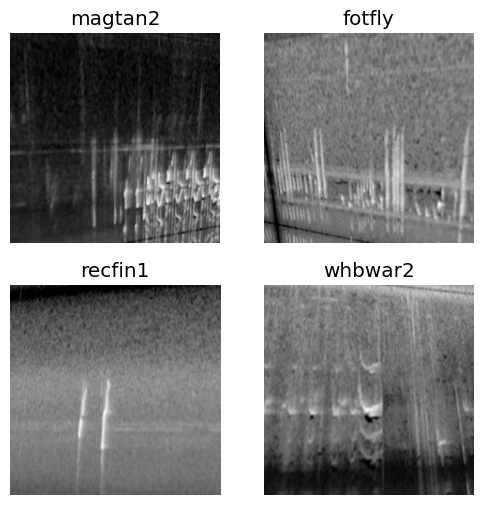

In [8]:
BATCH_SIZE = 64
IMG_SIZE = 224

dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock(vocab=ALL_SPECIES)),
    splitter=ColSplitter('is_valid'),
    get_x=ColReader('image_path'),
    get_y=ColReader('labels', label_delim=';'),
    item_tfms=Resize(IMG_SIZE),
    batch_tfms=aug_transforms(size=IMG_SIZE, do_flip=False, max_rotate=0.0),
)
dls = dblock.dataloaders(df, bs=BATCH_SIZE)

assert list(dls.vocab) == ALL_SPECIES, 'vocab order must match sample_submission column order'
print(f'vocab size: {len(dls.vocab)}  train batches: {len(dls.train)}  valid batches: {len(dls.valid)}')
dls.show_batch(max_n=4, nrows=2)

## Class imbalance via BCE `pos_weight`

`pos_weight[c] = (N - n_c) / n_c`, clipped to `[1, 50]`. Computed only on the training split so we don't peek at validation.

In [9]:
train_df = df[~df['is_valid']]
N = len(train_df)
pos_counts = pd.Series(0, index=ALL_SPECIES, dtype='int64')
for s in train_df['labels']:
    for lab in s.split(';'):
        pos_counts[lab] += 1

pos_counts = pos_counts.replace(0, 1)  # avoid division by zero for absent classes
raw = (N - pos_counts) / pos_counts
pos_weight = raw.clip(lower=1.0, upper=50.0).astype('float32')
pos_weight_t = torch.tensor(pos_weight.values, device=dls.device)

print('pos_weight summary:')
print(pos_weight.describe())
print('\nlowest-positive classes (most upweighted):')
print(pos_counts.sort_values().head(15))

pos_weight summary:
count    234.0
mean      50.0
std        0.0
min       50.0
25%       50.0
50%       50.0
75%       50.0
max       50.0
dtype: float64

lowest-positive classes (most upweighted):
1161364       1
22956         1
22985         1
25073         1
47158son11    1
47158son12    1
47158son09    1
47158son05    1
47158son19    1
47158son20    1
476521        1
47158son24    1
blheag1       1
baffal1       1
738183        1
dtype: int64


## Learner

In [10]:
loss_func = BCEWithLogitsLossFlat(pos_weight=pos_weight_t)
metrics = [accuracy_multi, APScoreMulti(average='macro')]

learn = vision_learner(
    dls,
    'convnext_base',
    loss_func=loss_func,
    metrics=metrics,
    n_out=len(ALL_SPECIES),
).to_fp16()
learn.summary

model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

<bound method Learner.summary of <fastai.learner.Learner object at 0x7dba3459acf0>>

## Train

In [11]:
learn.fine_tune(2)


epoch,train_loss,valid_loss,accuracy_multi,average_precision_score,time
0,0.320442,1.926001,0.949503,0.030390,11:01


epoch,train_loss,valid_loss,accuracy_multi,average_precision_score,time
0,0.212634,2.141793,0.960262,0.046521,14:40
1,0.180847,2.189054,0.964478,0.044547,14:35


In [12]:
learn.fit_one_cycle(5, lr_max=1e-4)


epoch,train_loss,valid_loss,accuracy_multi,average_precision_score,time
0,0.168720,2.268306,0.966431,0.050436,14:35
1,0.139993,2.209987,0.969161,0.046233,14:36
2,0.107731,2.256899,0.972939,0.055406,14:36
3,0.081901,2.236669,0.974806,0.056981,14:36
4,0.070738,2.238347,0.976079,0.056813,14:36


## Export model + vocab

In [13]:
learn.export('model_multilabel_234.pkl')
with open('vocab.json', 'w') as fp:
    json.dump(list(dls.vocab), fp)
print('Saved model_multilabel_234.pkl and vocab.json')

Saved model_multilabel_234.pkl and vocab.json


## Verification: per-class AP for the missing-28

The 28 species absent from `train_audio` (3 frogs + 25 insect sonotypes) are the entire reason this notebook exists. We compute their average precision on the validation split and flag any class whose AP is near zero so we know whether the soundscape supervision actually transferred.

In [14]:
train_csv = pd.read_csv(competition_dir / 'train.csv')
taxonomy_csv = pd.read_csv(competition_dir / 'taxonomy.csv')
train_audio_species = set(train_csv['primary_label'].unique())
missing28 = sorted(set(taxonomy_csv['primary_label']) - train_audio_species)
assert len(missing28) == 28, f'expected 28 missing, got {len(missing28)}'
print('Missing-28 classes:', missing28)

Missing-28 classes: ['1491113', '25073', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '47158son13', '47158son14', '47158son15', '47158son16', '47158son17', '47158son18', '47158son19', '47158son20', '47158son21', '47158son22', '47158son23', '47158son24', '47158son25', '517063']


In [15]:
preds, targs = learn.get_preds(dl=dls.valid)
preds_np = preds.cpu().numpy()
targs_np = targs.cpu().numpy()
vocab_index = {name: i for i, name in enumerate(dls.vocab)}

report_rows = []
for sp in missing28:
    j = vocab_index[sp]
    n_pos = int(targs_np[:, j].sum())
    if n_pos == 0:
        ap = float('nan')
    else:
        ap = float(average_precision_score(targs_np[:, j], preds_np[:, j]))
    report_rows.append({'species': sp, 'val_positives': n_pos, 'ap': ap})

report = pd.DataFrame(report_rows).sort_values('ap', na_position='last')
print(report.to_string(index=False))

low_ap = report[(report['val_positives'] > 0) & (report['ap'] < 0.05)]
no_val = report[report['val_positives'] == 0]
print(f'\nMissing-28 with AP < 0.05 (likely collapsed): {len(low_ap)}')
if len(low_ap):
    print(low_ap['species'].tolist())
print(f'Missing-28 with no validation positives (split too small for them): {len(no_val)}')
if len(no_val):
    print(no_val['species'].tolist())

   species  val_positives       ap
     25073             12 0.000510
47158son05              2 0.000520
47158son04              5 0.002039
47158son13             12 0.002246
47158son12              5 0.002735
47158son09              6 0.003800
47158son24             24 0.003882
47158son03              9 0.028273
47158son01             11 0.110027
   1491113             24 0.138258
47158son11             36 0.237958
47158son08             12 0.251022
47158son19              4 0.323810
    517063             78 0.682278
47158son20             12 0.761616
47158son25             12 0.845839
47158son17             12 0.856152
47158son07             12 1.000000
47158son02              0      NaN
47158son06              0      NaN
47158son10              0      NaN
47158son14              0      NaN
47158son15              0      NaN
47158son16              0      NaN
47158son18              0      NaN
47158son21              0      NaN
47158son22              0      NaN
47158son23          

In [16]:
# Macro-AP across all 234 classes (only those with >=1 validation positive count)
aps = []
for j in range(targs_np.shape[1]):
    if targs_np[:, j].sum() == 0:
        continue
    aps.append(average_precision_score(targs_np[:, j], preds_np[:, j]))
print(f'Macro-AP over {len(aps)} classes with validation positives: {np.mean(aps):.4f}')

Macro-AP over 79 classes with validation positives: 0.1683
